In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


In [6]:
df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

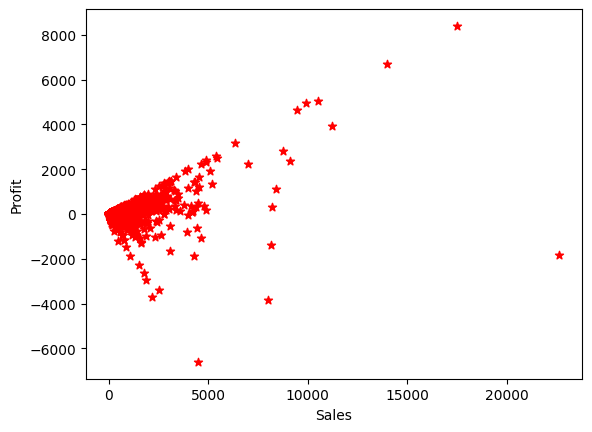

In [22]:
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.scatter(df['Sales'],df['Profit'],color='red',marker='*')

In [9]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

y = df['Profit']

X = df.drop(columns=['Profit', 'Row ID', 'Order ID', 'Customer ID', 'Customer Name',
                   'Product ID', 'Product Name', 'Order Date', 'Ship Date',
                   'Postal Code', 'City', 'State', 'Country'])

numerical_features = ['Sales', 'Quantity', 'Discount']
categorical_features = ['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category']

numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (7995, 8)
Shape of X_test: (1999, 8)
Shape of y_train: (7995,)
Shape of y_test: (1999,)


In [17]:
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

lasso_model = Pipeline([
    ('preprocessor', preprocessor),
    ('lasso', Lasso(alpha=0.1, random_state=42))
])

# Train the Lasso model
lasso_model.fit(X_train, y_train)

# Make predictions on the test set
pred_lasso = lasso_model.predict(X_test)

# Evaluate the Lasso model
print("Lasso Regression")
print(f"R2: {r2_score(y_test, pred_lasso):.4f}")
print(f"MAE: {mean_absolute_error(y_test, pred_lasso):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, pred_lasso)):.4f}")

Lasso Regression
R2: -0.6459
MAE: 67.4308
RMSE: 282.4891


In [26]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

poly_model = Pipeline([
    ('preprocessor', preprocessor),
    ('poly_features', PolynomialFeatures(degree=2, include_bias=False)), # Adjust degree as needed
    ('linear_reg', LinearRegression())
])

poly_model.fit(X_train, y_train)

pred_poly = poly_model.predict(X_test)

print("Polynomial Regression")
print(f"R2: {r2_score(y_test, pred_poly):.4f}")
print(f"MAE: {mean_absolute_error(y_test, pred_poly):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, pred_poly)):.4f}")

Polynomial Regression
R2: -0.2323
MAE: 31.6284
RMSE: 244.4385


In [27]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

gradient_boost_model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42))
])

gradient_boost_model_pipeline.fit(X_train, y_train)

y_pred_gradient_boost = gradient_boost_model_pipeline.predict(X_test)

mse_gradient_boost = mean_squared_error(y_test, y_pred_gradient_boost)
r2_gradient_boost = r2_score(y_test, y_pred_gradient_boost)

print(f"Gradient Boosting Regression - R-squared: {r2_gradient_boost:.4f}")
print(f"Gradient Boosting Regression - Mean Squared Error (MSE): {mse_gradient_boost:.2f}")

Gradient Boosting Regression - R-squared: 0.1771
Gradient Boosting Regression - Mean Squared Error (MSE): 39899.42


In [30]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline

base_estimator = DecisionTreeRegressor(max_depth=4, random_state=42)

adaboost_model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', AdaBoostRegressor(estimator=base_estimator, n_estimators=100, random_state=42))
])

adaboost_model_pipeline.fit(X_train, y_train)

y_pred_adaboost = adaboost_model_pipeline.predict(X_test)

mse_adaboost = mean_squared_error(y_test, y_pred_adaboost)
r2_adaboost = r2_score(y_test, y_pred_adaboost)

print(f"AdaBoost Regression - R-squared: {r2_adaboost:.4f}")
print(f"AdaBoost Regression - Mean Squared Error (MSE): {mse_adaboost:.2f}")

AdaBoost Regression - R-squared: 0.0054
AdaBoost Regression - Mean Squared Error (MSE): 48221.92
